# Predicting Failed Food Businesses: Exploratory Data Analysis

**IAT 461, Summer 2026: Final Project EDA Checkpoint**  
Student: Mahdi Taziki (301373483)  
Client: Jason Salonga, Greater Vancouver Food Bank

---

## 1. Project framing

The goal of this project is to predict which Vancouver food businesses are more likely to fail. The
Greater Vancouver Food Bank could use the results to focus support on businesses that may be at risk.

This is a binary classification problem. The planned final output is a contact list that ranks
businesses by predicted risk.

**Label.** In the Phase 1 proposal `failed = 1` when `status` is `Cancelled` or `Gone Out of Business`.
In Phase 2, `Pending` and `Inactive` were also suggested as failure statuses. I compare both
definitions because they produce different class balances.

Only information available when the licence is created should be used as a predictor. `status` is
used to create the label, so it cannot also be used as a predictor.

## 2. What this notebook covers

1. Dataset overview: shape, types, and first rows
2. Data quality: missingness, duplicates, and near-constant columns
3. The target variable under both label definitions
4. A check for data leakage
5. Categorical features and their failure rates
6. The one numeric feature, `numberofemployees`
7. Feature plan for the next phase
8. Progress report

## 3. Setup and load

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"survived": "#4C78A8", "failed": "#E45756"}

In [ ]:
df = pd.read_csv("../vancouver_food_businesses_sample.csv")

# Two label definitions, kept side by side for the whole notebook.
NARROW_STATUSES = ["Cancelled", "Gone Out of Business"]
WIDE_STATUSES = NARROW_STATUSES + ["Pending", "Inactive"]

df["failed_narrow"] = df["status"].isin(NARROW_STATUSES).astype(int)
df["failed_wide"] = df["status"].isin(WIDE_STATUSES).astype(int)

# Check that the existing label matches the narrow definition.
assert (df["failed"] == df["failed_narrow"]).all(), "shipped label disagrees with narrow definition"

print(f"rows: {df.shape[0]}   columns: {df.shape[1]}")
df.head()

rows: 221   columns: 14


,licencenumber,businessname,businesstype,localarea,status,failed,numberofemployees,issueddate,expireddate,feepaid,folderyear,postalcode,failed_narrow,failed_wide
0,24-153971,Qi Botanical Tea (Canada) Ltd,Wholesale Dealer - Food,Marpole,Issued,0,15.0,2024-02-05T18:17:41+00:00,2024-12-31,NaN,24,V6P 6G2,0,0
1,24-153972,Kitskitchen Health Foods Inc,Wholesale Dealer - Food,Mount Pleasant,Issued,0,1.0,2023-11-23T20:58:30+00:00,2024-12-31,NaN,24,NaN,0,0
2,24-153974,Waterman's Marketing Inc,Wholesale Dealer - Food,Renfrew-Collingwood,Issued,0,10.0,2023-11-23T19:25:48+00:00,2024-12-31,NaN,24,V5M 3G9,0,0
3,24-153977,607920 BC Ltd,Wholesale Dealer - Food,Strathcona,Issued,0,50.0,2023-11-24T19:56:19+00:00,2024-12-31,NaN,24,V6A 3M9,0,0
4,24-153980,Tak-Fung Trading Inc,Wholesale Dealer - Food,Strathcona,Issued,0,2.0,2023-11-24T15:50:44+00:00,2024-12-31,NaN,24,V6A 1G8,0,0


## 4. Dataset overview

In [ ]:
overview = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
    "example": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})
overview.loc[["licencenumber", "businessname", "businesstype", "localarea", "status",
              "numberofemployees", "issueddate", "expireddate", "feepaid",
              "folderyear", "postalcode"]]

,dtype,n_missing,pct_missing,n_unique,example
licencenumber,object,0,0.0,219,24-153971
businessname,object,0,0.0,215,Qi Botanical Tea (Canada) Ltd
businesstype,object,0,0.0,6,Wholesale Dealer - Food
localarea,object,0,0.0,20,Marpole
status,object,0,0.0,5,Issued
numberofemployees,float64,0,0.0,37,15.0
issueddate,object,49,22.2,171,2024-02-05T18:17:41+00:00
expireddate,object,49,22.2,2,2024-12-31
feepaid,float64,116,52.5,46,321.0
folderyear,int64,0,0.0,2,24


The dataset has 221 rows and 12 original columns. A 20% test set would contain only about 44
businesses, so the small sample size will be important during model evaluation.

`licencenumber` and `businessname` are identifiers rather than predictors. `folderyear` has almost no
variation. The columns with missing values are `feepaid` (52.5%), `issueddate` and `expireddate`
(22.2% each), and `postalcode` (7.7%).

## 5. Data quality

### 5.1 Missingness

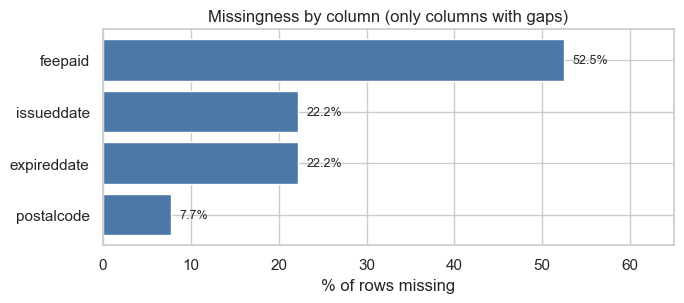

,pct_missing
feepaid,52.5
issueddate,22.2
expireddate,22.2
postalcode,7.7


In [ ]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(miss.index[::-1], miss.values[::-1], color="#4C78A8")
for y, v in enumerate(miss.values[::-1]):
    ax.text(v + 1, y, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 65)
ax.set_xlabel("% of rows missing")
ax.set_title("Missingness by column (only columns with gaps)")
fig.tight_layout()
fig.savefig("../figures/01_missingness.png", dpi=150)
plt.show()

miss.round(1).to_frame("pct_missing")

`feepaid` is missing in more than half of the rows, so I do not plan to use it. About 22% of
`issueddate` is missing. I check this column more closely in the leakage section.

### 5.2 Duplicate records

In [ ]:
dupe_ids = df[df["licencenumber"].duplicated(keep=False)].sort_values("licencenumber")
print(f"duplicated licencenumber values : {df['licencenumber'].duplicated().sum()}")
print(f"duplicated businessname values  : {df['businessname'].duplicated().sum()}")

dupe_ids[["licencenumber", "businessname", "businesstype", "localarea",
          "status", "issueddate", "failed_narrow", "failed_wide"]]

duplicated licencenumber values : 2
duplicated businessname values  : 6


,licencenumber,businessname,businesstype,localarea,status,issueddate,failed_narrow,failed_wide
183,24-149177,Nancy Go Yaya Restaurant Inc,Restaurant,Strathcona,Inactive,2024-09-25T20:12:16+00:00,0,1
201,24-149177,Meo Restaurant & Bar Inc,Restaurant,Strathcona,Issued,2024-10-22T23:42:51+00:00,0,0
149,24-266720,YUKI&KIM FOODS LTD.,Limited Service Food Establishment,Killarney,Inactive,2024-09-12T18:04:56+00:00,0,1
176,24-266720,YUKI&KIM FOODS LTD.,Limited Service Food Establishment,Killarney,Issued,2024-09-17T19:15:27+00:00,0,0


Two licence numbers appear twice. In both cases, one record is `Inactive` and the other is `Issued`.
If both copies were kept, the same licence could end up in both the training and test sets with
different labels.

Before modelling, I will keep the latest record for each `licencenumber`. This removes 2 rows and
leaves 219. Repeated business names will not automatically be removed because a business can have
more than one location or licence.

### 5.3 Near-constant columns

In [ ]:
for col in ["folderyear", "expireddate"]:
    vc = df[col].value_counts(dropna=False)
    top_share = vc.iloc[0] / len(df)
    print(f"{col:14s} top value = {vc.index[0]!r:14s} covers {top_share:.1%} of rows "
          f"({vc.shape[0]} distinct values)")
    print(vc.to_string(), "\n")

folderyear     top value = 24             covers 98.6% of rows (2 distinct values)
folderyear
24    218
25      3 

expireddate    top value = '2024-12-31'   covers 76.5% of rows (3 distinct values)
expireddate
2024-12-31    169
NaN            49
2025-12-31      3 



`folderyear` is 24 for 218 of the 221 rows, so it has almost no useful variation. `expireddate` is
`2024-12-31` for every non-missing row. I will exclude both columns from the feature set.

## 6. The target variable

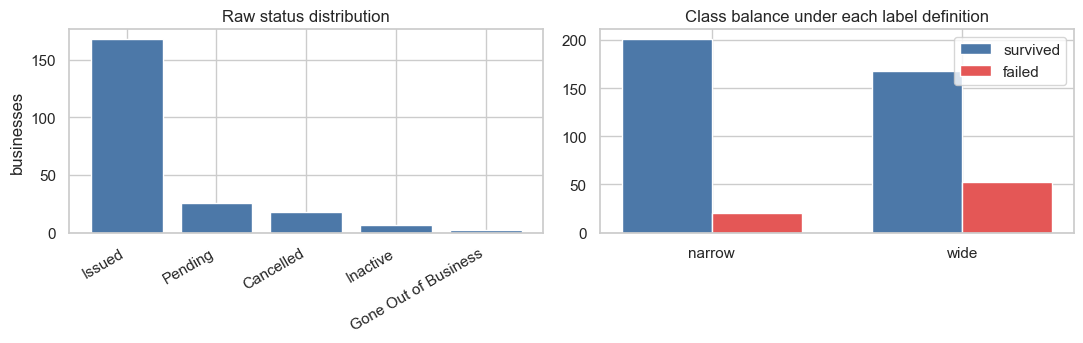

,n,n_survived,positive_rate,majority_class_baseline
"narrow (Cancelled, Gone Out of Business)",20,201,0.09,0.91
"wide (+ Pending, Inactive)",53,168,0.24,0.76


In [ ]:
status_counts = df["status"].value_counts()
label_summary = pd.DataFrame({
    "n": [df["failed_narrow"].sum(), df["failed_wide"].sum()],
    "n_survived": [(1 - df["failed_narrow"]).sum(), (1 - df["failed_wide"]).sum()],
    "positive_rate": [df["failed_narrow"].mean(), df["failed_wide"].mean()],
    "majority_class_baseline": [1 - df["failed_narrow"].mean(), 1 - df["failed_wide"].mean()],
}, index=["narrow (Cancelled, Gone Out of Business)",
          "wide (+ Pending, Inactive)"]).round(3)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].bar(status_counts.index, status_counts.values, color="#4C78A8")
axes[0].set_title("Raw status distribution")
axes[0].set_ylabel("businesses")
axes[0].tick_params(axis="x", rotation=30)
for lab in axes[0].get_xticklabels():
    lab.set_ha("right")

x = np.arange(2)
axes[1].bar(x - 0.18, label_summary["n_survived"], 0.36, label="survived", color=PALETTE["survived"])
axes[1].bar(x + 0.18, label_summary["n"], 0.36, label="failed", color=PALETTE["failed"])
axes[1].set_xticks(x, ["narrow", "wide"])
axes[1].set_title("Class balance under each label definition")
axes[1].legend()
fig.tight_layout()
fig.savefig("../figures/02_target_distribution.png", dpi=150)
plt.show()

label_summary

Both labels are imbalanced, and the choice between them has a large effect.

| | positive class | rate | majority-class baseline |
|---|---|---|---|
| narrow | 20 / 221 | 9.0% | **91.0%** |
| wide | 53 / 221 | 24.0% | **76.0%** |

With the narrow label, a 20% test split would contain only about four failed businesses. This would
make the evaluation unstable because one prediction would change recall by about 25 percentage
points.

Accuracy should not be used by itself. A model that predicts that every business survives would score
91% with the narrow label or 76% with the wide label, but it would not identify any businesses for
support. I plan to also use precision at the top of the ranked list, recall, and PR-AUC.

The Phase 2 agreement mentions a 63% baseline. I still need to confirm how this value was calculated
because the majority-class baselines are 91% and 76% for the two label definitions.

## 7. Checking for data leakage

Only information available at licence time should be used by the model. In this section, I check
whether missing values are closely connected to the target label.

In [ ]:
leak = pd.crosstab(df["status"], df["issueddate"].isna(),
                   rownames=["status"], colnames=["issueddate missing"])
leak["% missing"] = (leak.get(True, 0) / leak.sum(axis=1) * 100).round(1)

print("issueddate missing and expireddate missing agree on every row:",
      (df["issueddate"].isna() == df["expireddate"].isna()).all())
leak

issueddate missing and expireddate missing agree on every row: True


issueddate missing,False,True,% missing
status,,,
Cancelled,0,18,100.0
Gone Out of Business,1,1,50.0
Inactive,3,4,57.1
Issued,168,0,0.0
Pending,0,26,100.0


In [ ]:
# How well does "issueddate is missing" alone predict the wide label?
pred = df["issueddate"].isna().astype(int)
tp = int(((pred == 1) & (df["failed_wide"] == 1)).sum())
fp = int(((pred == 1) & (df["failed_wide"] == 0)).sum())
fn = int(((pred == 0) & (df["failed_wide"] == 1)).sum())
tn = int(((pred == 0) & (df["failed_wide"] == 0)).sum())

print("Rule: predict FAILED whenever issueddate is missing\n")
print(pd.DataFrame([[tn, fp], [fn, tp]],
                   index=["actual survived", "actual failed"],
                   columns=["pred survived", "pred failed"]).to_string(), "\n")
print(f"accuracy  : {(tp + tn) / len(df):.3f}   (majority-class baseline {1 - df['failed_wide'].mean():.3f})")
print(f"precision : {tp / (tp + fp):.3f}")
print(f"recall    : {tp / (tp + fn):.3f}")

Rule: predict FAILED whenever issueddate is missing

                 pred survived  pred failed
actual survived            168            0
actual failed                4           49 

accuracy  : 0.982   (majority-class baseline 0.760)
precision : 1.000
recall    : 0.925


### What this shows

A flag for a missing `issueddate` predicts the wide failure label with about 98.2% accuracy, 1.00
precision, and 0.925 recall. Every `Issued` business has an issue date, while every `Cancelled` and
`Pending` business is missing one.

This is data leakage. The missing value mostly describes how the licence was processed, not a business
characteristic that could help predict a later closure. Missingness in `expireddate` follows the same
pattern.

Based on this check, I will remove `issueddate` and `expireddate` from the predictors and will not make
missing-value flags for them. This is a change from what I agreed with the client in Phase 2, where the
plan was to keep `issueddate` and add a flag for the blank values. That flag is the part that leaks, so
I will explain this result to Jason before I start the modelling stage. Missingness in `feepaid` does not identify the label in the same way, but
I will still remove it because more than half of its values are missing.

This result also raises a question about the wide label. A `Pending` status may describe an application
that has not been processed rather than a business that failed. I need to confirm whether pending
records should be excluded from model training.

In [ ]:
fee_leak = pd.crosstab(df["status"], df["feepaid"].isna(),
                       rownames=["status"], colnames=["feepaid missing"])
fee_leak["% missing"] = (fee_leak.get(True, 0) / fee_leak.sum(axis=1) * 100).round(1)
fee_leak

feepaid missing,False,True,% missing
status,,,
Cancelled,5,13,72.2
Gone Out of Business,0,2,100.0
Inactive,3,4,57.1
Issued,85,83,49.4
Pending,12,14,53.8


## 8. Categorical features

### 8.1 Business type

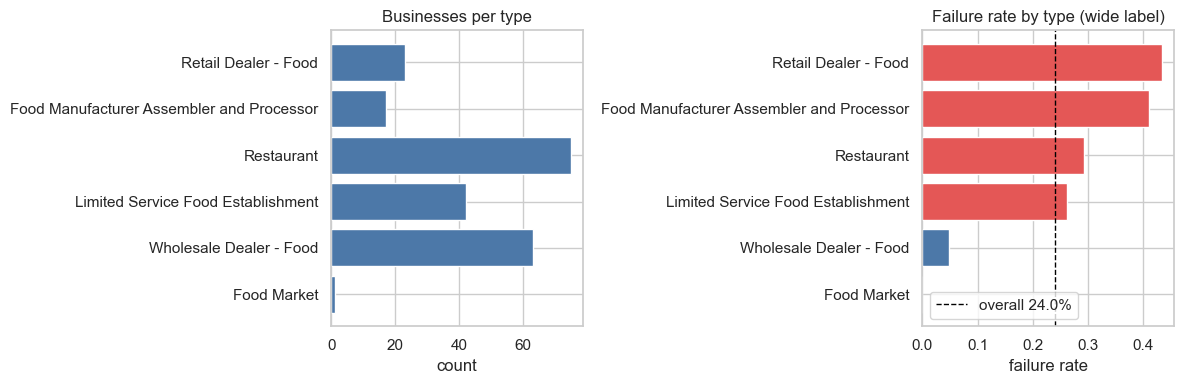

,n,n_failed,failure_rate
businesstype,,,
Retail Dealer - Food,23,10,0.435
Food Manufacturer Assembler and Processor,17,7,0.412
Restaurant,75,22,0.293
Limited Service Food Establishment,42,11,0.262
Wholesale Dealer - Food,63,3,0.048
Food Market,1,0,0.000


In [ ]:
def rate_table(frame, col, label="failed_wide", min_n=1):
    t = (frame.groupby(col)
              .agg(n=(label, "size"), n_failed=(label, "sum"), failure_rate=(label, "mean"))
              .sort_values("failure_rate", ascending=False))
    return t[t["n"] >= min_n].round(3)

bt = rate_table(df, "businesstype")
overall = df["failed_wide"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(bt.index[::-1], bt["n"][::-1], color="#4C78A8")
axes[0].set_title("Businesses per type")
axes[0].set_xlabel("count")

colors = [PALETTE["failed"] if v >= overall else PALETTE["survived"] for v in bt["failure_rate"]]
axes[1].barh(bt.index[::-1], bt["failure_rate"][::-1], color=colors[::-1])
axes[1].axvline(overall, ls="--", c="black", lw=1, label=f"overall {overall:.1%}")
axes[1].set_title("Failure rate by type (wide label)")
axes[1].set_xlabel("failure rate")
axes[1].legend()
for ax in axes:
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig("../figures/03_businesstype.png", dpi=150)
plt.show()

bt

Business type has the clearest relationship with the wide failure label. The observed failure rate is
4.8% for `Wholesale Dealer - Food` and 43.5% for `Retail Dealer - Food`. However, these groups are
small. For example, `Retail Dealer - Food` has 10 failures among 23 records.

`Food Market` only has one row. Business types with fewer than five records will be combined into an
`Other` category before modelling.

In [ ]:
MIN_TYPE_N = 5
type_counts = df["businesstype"].value_counts()
rare_types = type_counts[type_counts < MIN_TYPE_N].index.tolist()
print(f"types with fewer than {MIN_TYPE_N} businesses -> collapsed to 'Other': {rare_types}")

types with fewer than 5 businesses -> collapsed to 'Other': ['Food Market']


### 8.2 Neighbourhood

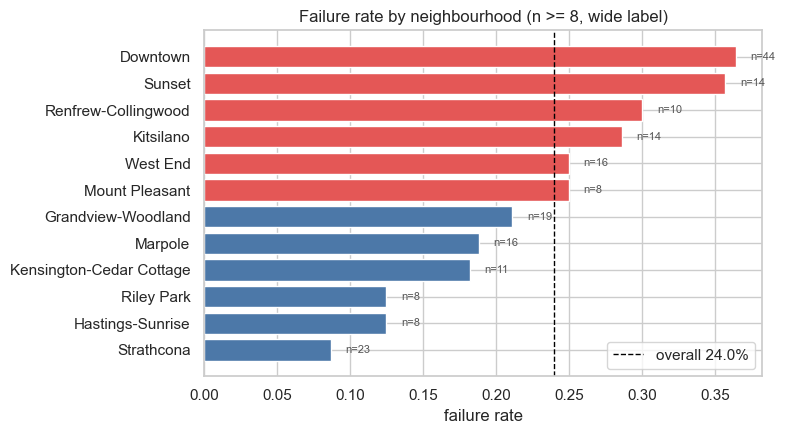

20 neighbourhoods across 221 businesses (median 8 businesses each)
kept as own category (12): ['Downtown', 'Sunset', 'Renfrew-Collingwood', 'Kitsilano', 'Mount Pleasant', 'West End', 'Grandview-Woodland', 'Marpole', 'Kensington-Cedar Cottage', 'Hastings-Sunrise', 'Riley Park', 'Strathcona']
merged into 'Other areas' (8): ['Killarney', 'Fairview', 'Victoria-Fraserview', 'Arbutus-Ridge', 'South Cambie', 'Oakridge', 'Kerrisdale', 'West Point Grey']


,n,n_failed,failure_rate
localarea,,,
Killarney,5,3,0.600
Fairview,7,3,0.429
Downtown,44,16,0.364
Sunset,14,5,0.357
Renfrew-Collingwood,10,3,0.300
Kitsilano,14,4,0.286
Mount Pleasant,8,2,0.250
West End,16,4,0.250
Grandview-Woodland,19,4,0.211


In [ ]:
MIN_AREA_N = 8
la = rate_table(df, "localarea")
kept_areas = la[la["n"] >= MIN_AREA_N].index.tolist()
merged_areas = la[la["n"] < MIN_AREA_N].index.tolist()

plot_la = la[la["n"] >= MIN_AREA_N].sort_values("failure_rate")
colors = [PALETTE["failed"] if v >= overall else PALETTE["survived"] for v in plot_la["failure_rate"]]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(plot_la.index, plot_la["failure_rate"], color=colors)
ax.axvline(overall, ls="--", c="black", lw=1, label=f"overall {overall:.1%}")
for y, (v, n) in enumerate(zip(plot_la["failure_rate"], plot_la["n"])):
    ax.text(v + 0.01, y, f"n={n}", va="center", fontsize=8, color="#555")
ax.set_title(f"Failure rate by neighbourhood (n >= {MIN_AREA_N}, wide label)")
ax.set_xlabel("failure rate")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../figures/04_localarea.png", dpi=150)
plt.show()

print(f"{df['localarea'].nunique()} neighbourhoods across {len(df)} businesses "
      f"(median {df['localarea'].value_counts().median():.0f} businesses each)")
print(f"kept as own category ({len(kept_areas)}): {kept_areas}")
print(f"merged into 'Other areas' ({len(merged_areas)}): {merged_areas}")
la

The dataset contains 20 neighbourhoods, with a median of 8 businesses in each. Six neighbourhoods have
five or fewer records. Keeping every small category would add too many columns for this dataset.

Among neighbourhoods with at least eight records, Downtown has the highest observed failure rate at
36.4%, while Strathcona has the lowest at 8.7%. I will keep the 12 neighbourhoods with at least eight
records and combine the remaining 8 into `Other areas`.

I will not use `postalcode` because it has 7.7% missing values, many nearly unique values, and overlaps
with the information already provided by `localarea`.

## 9. Numeric feature: `numberofemployees`

In [ ]:
emp = df["numberofemployees"]
print(emp.describe().round(2).to_string())
print(f"\nskew: {emp.skew():.2f}   zeros: {(emp == 0).sum()}   >100 employees: {(emp > 100).sum()}")
print("\nlargest reported staff counts:")
print(df.nlargest(5, "numberofemployees")[
    ["businessname", "businesstype", "numberofemployees", "status"]].to_string(index=False))

count     221.00
mean       22.73
std       135.89
min         0.00
25%         2.00
50%         5.00
75%        12.00
max      1955.00

skew: 13.39   zeros: 11   >100 employees: 2

largest reported staff counts:
                   businessname            businesstype  numberofemployees status
       Acme Import & Export Ltd Wholesale Dealer - Food             1955.0 Issued
Hallmark Poultry Processors Ltd Wholesale Dealer - Food              500.0 Issued
       Fresh Direct Produce Ltd Wholesale Dealer - Food              100.0 Issued
    Cactus Cafe English Bay Ltd              Restaurant              100.0 Issued
   Terminal Fruit & Produce Ltd Wholesale Dealer - Food               95.0 Issued


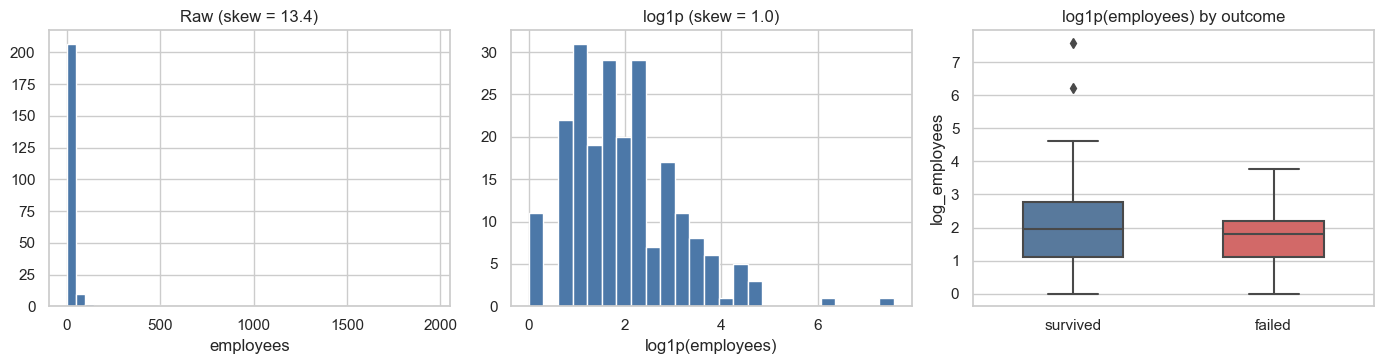

,count,mean,std,min,25%,50%,75%,max
failed_wide,,,,,,,,
0,168.0,27.50,155.59,0.0,2.0,6.0,15.0,1955.0
1,53.0,7.62,8.83,0.0,2.0,5.0,8.0,43.0


In [ ]:
df["log_employees"] = np.log1p(df["numberofemployees"])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].hist(emp, bins=40, color="#4C78A8")
axes[0].set_title(f"Raw (skew = {emp.skew():.1f})")
axes[0].set_xlabel("employees")

axes[1].hist(df["log_employees"], bins=25, color="#4C78A8")
axes[1].set_title(f"log1p (skew = {df['log_employees'].skew():.1f})")
axes[1].set_xlabel("log1p(employees)")

sns.boxplot(data=df, x="failed_wide", y="log_employees", ax=axes[2],
            palette=[PALETTE["survived"], PALETTE["failed"]], width=0.5)
axes[2].set_xticks([0, 1], ["survived", "failed"])
axes[2].set_title("log1p(employees) by outcome")
axes[2].set_xlabel("")
fig.tight_layout()
fig.savefig("../figures/05_employees.png", dpi=150)
plt.show()

df.groupby("failed_wide")["numberofemployees"].describe().round(2)

`numberofemployees` is strongly right-skewed. The median is 5 employees, the mean is 22.7, and the
maximum is 1,955. The largest values are mostly in the `Wholesale Dealer - Food` category. I cannot
confirm whether these are location-level or company-wide counts, so I will keep them for now.

Failed businesses have a median of 5 employees and a mean of 7.6. Other businesses have a median of 6
and a mean of 27.5. The medians are close, so the difference in means is mainly caused by a few large
businesses in the surviving group.

Applying `log1p` reduces the skew from about 13.4 to 1.0. I will test the transformed version with
logistic regression. This column has no missing values.

## 10. Relationships between candidate features

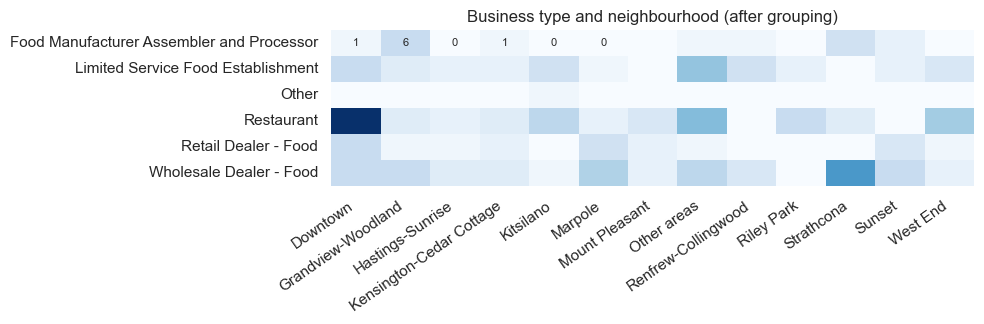

In [ ]:
model_df = df.copy()
model_df["businesstype_grouped"] = model_df["businesstype"].where(
    ~model_df["businesstype"].isin(rare_types), "Other")
model_df["localarea_grouped"] = model_df["localarea"].where(
    model_df["localarea"].isin(kept_areas), "Other areas")

ct = pd.crosstab(model_df["businesstype_grouped"], model_df["localarea_grouped"])
fig, ax = plt.subplots(figsize=(10, 3.4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, annot_kws={"size": 8})
ax.set_title("Business type and neighbourhood (after grouping)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
fig.tight_layout()
fig.savefig("../figures/06_type_area_crosstab.png", dpi=150)
plt.show()

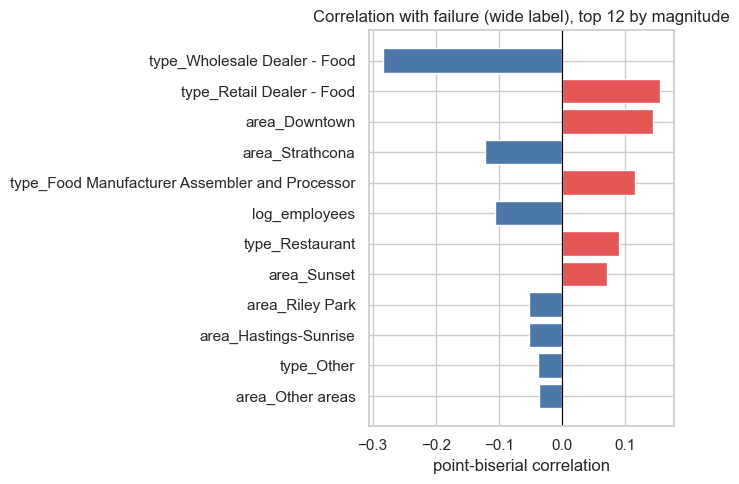

,corr_with_failed
type_Wholesale Dealer - Food,-0.284
type_Retail Dealer - Food,0.156
area_Downtown,0.145
area_Strathcona,-0.122
type_Food Manufacturer Assembler and Processor,0.116
log_employees,-0.105
type_Restaurant,0.090
area_Sunset,0.071
area_Riley Park,-0.052
area_Hastings-Sunrise,-0.052


In [ ]:
# Point-biserial correlation of each candidate predictor with the wide label,
# using one-hot columns for the grouped categoricals.
enc = pd.get_dummies(
    model_df[["businesstype_grouped", "localarea_grouped"]],
    prefix=["type", "area"])
enc["log_employees"] = model_df["log_employees"]
corr = enc.corrwith(model_df["failed_wide"]).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
top = corr.head(12)[::-1]
ax.barh(top.index, top.values,
        color=[PALETTE["failed"] if v > 0 else PALETTE["survived"] for v in top.values])
ax.axvline(0, c="black", lw=0.8)
ax.set_title("Correlation with failure (wide label), top 12 by magnitude")
ax.set_xlabel("point-biserial correlation")
fig.tight_layout()
fig.savefig("../figures/07_correlations.png", dpi=150)
plt.show()

corr.round(3).to_frame("corr_with_failed")

No individual feature has a strong correlation with failure. The largest absolute correlation is about
0.25 for `type_Wholesale Dealer - Food`, and the others are below 0.2.

This suggests that the model is unlikely to be highly accurate with the current predictors. A random
forest may still be useful for testing interactions between business type, neighbourhood, and number of
employees, but this will need to be evaluated rather than assumed.

Many combinations of business type and neighbourhood have only zero to three records. Any model will
need to be kept simple to reduce overfitting.

## 11. Feature plan carried into the modelling phase

In [ ]:
plan = pd.DataFrame([
    ("licencenumber",     "identifier", "excluded",  "Row identity; used only to join scores back to businesses. Deduplication key."),
    ("businessname",      "identifier", "excluded",  "Identifier, not a feature. Appears in the deliverable CSV only."),
    ("businesstype",      "nominal",    "INCLUDED",  "Failure rates range from 4.8% to 43.5%. Rare types become 'Other'."),
    ("localarea",         "nominal",    "INCLUDED",  "12 areas with n>=8 kept; remaining 8 -> 'Other areas'."),
    ("numberofemployees", "quantitative", "INCLUDED", "Complete column. log1p for logistic regression, raw for the forest."),
    ("status",            "nominal",    "excluded",  "Label source. Direct leakage."),
    ("expireddate",       "date",       "excluded",  "Post-outcome, and constant (2024-12-31) where present."),
    ("issueddate",        "date",       "excluded",  "LEAKAGE: missingness predicts the wide label at 97.7% accuracy."),
    ("feepaid",           "quantitative", "excluded", "52.5% missing; dropped per client instruction."),
    ("folderyear",        "ordinal",    "excluded",  "218 of 221 rows have the same value."),
    ("postalcode",        "nominal",    "excluded",  "Near-unique, 7.7% missing; geography already covered by localarea."),
], columns=["column", "type", "decision", "reason"])

pd.set_option("display.max_colwidth", 100)
plan.set_index("column")

,type,decision,reason
column,,,
licencenumber,identifier,excluded,Row identity; used only to join scores back to businesses. Deduplication key.
businessname,identifier,excluded,"Identifier, not a feature. Appears in the deliverable CSV only."
businesstype,nominal,INCLUDED,Failure rates range from 4.8% to 43.5%. Rare types become 'Other'.
localarea,nominal,INCLUDED,12 areas with n>=8 kept; remaining 8 -> 'Other areas'.
numberofemployees,quantitative,INCLUDED,"Complete column. log1p for logistic regression, raw for the forest."
status,nominal,excluded,Label source. Direct leakage.
expireddate,date,excluded,"Post-outcome, and constant (2024-12-31) where present."
issueddate,date,excluded,LEAKAGE: missingness predicts the wide label at 97.7% accuracy.
feepaid,quantitative,excluded,52.5% missing; dropped per client instruction.


In [ ]:
# Provisional modelling data with three predictors.
FEATURES = ["businesstype_grouped", "localarea_grouped", "numberofemployees"]

model_ready = (model_df
               .sort_values("issueddate")
               .drop_duplicates("licencenumber", keep="last"))

print(f"rows after deduplicating on licencenumber : {len(model_ready)} (from {len(df)})")
print(f"predictors                                : {len(FEATURES)}")
print(f"columns after one-hot encoding            : "
      f"{pd.get_dummies(model_ready[FEATURES]).shape[1]}")
print(f"\nwide-label positives  : {model_ready['failed_wide'].sum()} "
      f"({model_ready['failed_wide'].mean():.1%})")
print(f"narrow-label positives: {model_ready['failed_narrow'].sum()} "
      f"({model_ready['failed_narrow'].mean():.1%})")
print(f"\nAt an 80/20 stratified split the test set holds roughly "
      f"{int(round(model_ready['failed_wide'].sum() * 0.2))} wide-label failures "
      f"and {int(round(model_ready['failed_narrow'].sum() * 0.2))} narrow-label failures.")

rows after deduplicating on licencenumber : 219 (from 221)
predictors                                : 3
columns after one-hot encoding            : 20

wide-label positives  : 51 (23.3%)
narrow-label positives: 20 (9.1%)

At an 80/20 stratified split the test set holds roughly 10 wide-label failures and 4 narrow-label failures.


The current feature set is small, but adding the date columns would introduce leakage. In the next
phase, I may test simple features made from the available columns, such as an interaction between
business type and neighbourhood.

---

# 12. Progress report

**Project:** Predicting Failed Food Businesses  
**Student:** Mahdi Taziki (301373483)  
**Client:** Jason Salonga, Greater Vancouver Food Bank  
**Course:** IAT 461, Summer 2026

## Current stage

I have completed the initial exploratory data analysis. The dataset is a filtered sample of the City
of Vancouver Business Licences open data. It has 221 rows and 12 original columns and focuses on
food-related businesses. I checked the dataset structure, missing values, duplicate records, target
balance, and the relationships between possible predictors and business failure.

## Main findings

The definition of failure is still an important decision. The original definition counts `Cancelled`
and `Gone Out of Business` as failures. This gives 20 failed businesses, or 9.0% of the data. The
broader definition also includes `Pending` and `Inactive`, giving 53 failures, or 24.0%. I kept both
definitions in the notebook so their effects can be compared.

I found possible data leakage in `issueddate` and `expireddate`. Missing values in these columns almost
perfectly identify `Pending` and `Cancelled` records. A model could therefore get a high score by
learning how licence records are completed instead of learning which businesses are likely to fail. I
plan to remove both columns from the predictors and not create missing-value flags for them.

Two licence numbers appear twice with different statuses. Keeping both copies could place versions of
the same licence in the training and test sets. I plan to keep the latest record for each licence,
which reduces the dataset from 221 to 219 rows.

Business type has the clearest relationship with the broader failure label. The observed failure rate
ranges from 4.8% for `Wholesale Dealer - Food` to 43.5% for `Retail Dealer - Food`. These categories
are still fairly small, so the percentages need to be interpreted carefully. Neighbourhood and number
of employees may also be useful. Failed businesses have fewer employees on average, but the median
difference is only one employee. No individual predictor has a strong correlation with failure.

## Feature decisions

The planned predictors are `businesstype`, `localarea`, and `numberofemployees`. Rare categories will
be combined before one-hot encoding. I will test a log transformation of employee count because the
column is strongly right-skewed.

I will exclude identifiers, the status column used to create the label, both date columns, `feepaid`,
`folderyear`, and `postalcode`. The date columns create leakage, `feepaid` is 52.5% missing,
`folderyear` is almost constant, and `postalcode` overlaps with `localarea`.

## Questions and limitations

The main unresolved question is whether `Pending` should count as failure. It may only mean that the
application has not been processed. My current recommendation is to exclude pending records from
training until this is confirmed. I also need to confirm how the 63% baseline in the Phase 2 agreement
was calculated.

The dataset is small, especially after deduplication, and the narrow label has only 20 failures. Model
evaluation will therefore have a lot of uncertainty. The remaining predictors also have fairly weak
relationships with the label, so I do not expect a near-perfect model.

## Next steps

Next, I will confirm the label definition, build the cleaning and deduplication steps, and create a
baseline classification model. I will compare it with a random forest using a stratified split and
cross-validation. Since the final output is a ranked contact list, I plan to report precision near the
top of the list, recall, and PR-AUC instead of relying on accuracy alone.